# Decaying Turbulence — Low-Frequency Study

A dedicated notebook for extending the decaying-turbulence comparison into the lower-frequency band.
This is extracted from the final comparison cells of `workflow_demo.ipynb`, with a wider low-frequency grid,
separate cache files, and a dedicated low-frequency zoom. Run it from the `src/` directory.

## 1. Setup

We keep the same diagonal comparison $p=q$ used in the workflow notebook, but place extra sample points below
$q=10^{-4}$ so the decaying spectrum can be inspected further into the infrared.

The numerical settings remain intentionally coarse because `H_pq_decaying` is expensive.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

from gw_turbulence import H_pq, H_pq_decaying, LiveStatusLogger

%matplotlib inline

out_dir = os.path.abspath('outputs')
os.makedirs(out_dir, exist_ok=True)

M_compare = [0.1, 1.0]
R_dec, k0_dec = 1e3, 1.0

# Add dedicated resolution in the low-frequency band while keeping the total cost manageable.
# This extends the infrared coverage by five additional decades while keeping
# the same low-frequency sampling density as before.
low_log_step = (np.log10(1e-3) - np.log10(1e-6)) / 10.0
low_log_exponents = np.arange(np.log10(1e-11), np.log10(1e-3), low_log_step)
qs_low = 10.0 ** low_log_exponents
qs_main = np.logspace(np.log10(1e-3), np.log10(10.0), 18)
qs_dec = np.unique(np.concatenate([qs_low, qs_main]))
scaled_freq_dec = 1.55e-3 * qs_dec

cache_path = os.path.join(out_dir, 'stationary_vs_decaying_low_frequency_cache.npz')

print(f'Number of q points: {len(qs_dec)}')
print(f'q range: {qs_dec.min():.3e} -> {qs_dec.max():.3e}')
print(f'f range: {scaled_freq_dec.min():.3e} -> {scaled_freq_dec.max():.3e}')

Number of q points: 45
q range: 1.000e-11 -> 1.000e+01
f range: 1.550e-14 -> 1.550e-02


## 2. Compute and cache the spectra

This follows the same workflow as the last demo cells, but writes to a separate cache so the low-frequency study
can be rerun independently.

In [2]:
recompute_cache = True
if os.path.exists(cache_path):
    cached = np.load(cache_path)
    cached_qs = cached['qs_dec'] if 'qs_dec' in cached else None
    cached_machs = cached['M_compare'] if 'M_compare' in cached else None

    if (
        cached_qs is not None
        and cached_machs is not None
        and np.array_equal(cached_qs, qs_dec)
        and np.array_equal(cached_machs, np.array(M_compare, dtype=float))
    ):
        h_stat_all = cached['h_stat_all']
        h_dec_all = cached['h_dec_all']
        recompute_cache = False
        print(f'Loaded cached spectra: {cache_path}')
    else:
        print(f'Cache shape/grid mismatch, recomputing: {cache_path}')

if recompute_cache:
    status = LiveStatusLogger(prefix='decay-lowf', every_seconds=5.0)
    h_stat_all = np.zeros((len(M_compare), len(qs_dec)))
    h_dec_all = np.zeros((len(M_compare), len(qs_dec)))

    for m_idx, M in enumerate(M_compare):
        for i, q in enumerate(qs_dec):
            h_stat_all[m_idx, i] = H_pq(q, q, M=M, R=R_dec, k0=k0_dec, epsabs=1e-4, epsrel=1e-3)

        for i, q in enumerate(qs_dec):
            h_dec_all[m_idx, i] = H_pq_decaying(
                q, q, M=M, R=R_dec, k0=k0_dec,
                convolution_method='trapz', convolution_points=24,
                integration_method='sampled', x_points=8, y_points=8,
                status=status,
            )

    np.savez(
        cache_path,
        M_compare=np.array(M_compare, dtype=float),
        qs_dec=qs_dec,
        scaled_freq_dec=scaled_freq_dec,
        h_stat_all=h_stat_all,
        h_dec_all=h_dec_all,
        R_dec=R_dec,
        k0_dec=k0_dec,
    )
    print(f'Computed and cached spectra: {cache_path}')

Cache shape/grid mismatch, recomputing: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/stationary_vs_decaying_low_frequency_cache.npz
[decay-lowf] start H_pq_decaying p=1.000e-11 q=1.000e-11 M=1.000e-01 conv=trapz integ=sampled
[decay-lowf] done H_pq_decaying p=1.000e-11 q=1.000e-11 -> 2.456e-02
[decay-lowf] start H_pq_decaying p=1.995e-11 q=1.995e-11 M=1.000e-01 conv=trapz integ=sampled
[decay-lowf] done H_pq_decaying p=1.995e-11 q=1.995e-11 -> 2.456e-02
[decay-lowf] start H_pq_decaying p=3.981e-11 q=3.981e-11 M=1.000e-01 conv=trapz integ=sampled
[decay-lowf] done H_pq_decaying p=3.981e-11 q=3.981e-11 -> 2.456e-02
[decay-lowf] start H_pq_decaying p=7.943e-11 q=7.943e-11 M=1.000e-01 conv=trapz integ=sampled
[decay-lowf] done H_pq_decaying p=7.943e-11 q=7.943e-11 -> 2.456e-02
[decay-lowf] start H_pq_decaying p=1.585e-10 q=1.585e-10 M=1.000e-01 conv=trapz integ=sampled
[decay-lowf] done H_pq_decaying p=1.585e-10 q=1.585e-10 -> 2.456e-02
[decay-lowf] start H_pq

## 3. Convert to Gogoberidze-style normalized strain

The same normalization used in the workflow notebook is applied here so the low-frequency extension can be compared
directly with the previous figures.

In [3]:
def normalized_strain(q_values, h_values, mach_number):
    return 1.62e-18 * np.sqrt(np.clip(q_values * h_values, 0.0, None)) / mach_number**1.5


sc_stat_all = np.zeros_like(h_stat_all)
sc_dec_all = np.zeros_like(h_dec_all)

for m_idx, M in enumerate(M_compare):
    sc_stat_all[m_idx] = normalized_strain(qs_dec, h_stat_all[m_idx], M)
    sc_dec_all[m_idx] = normalized_strain(qs_dec, h_dec_all[m_idx], M)

## 4. Full-band comparison

This reproduces the stationary-vs-decaying comparison with the extended low-frequency coverage.

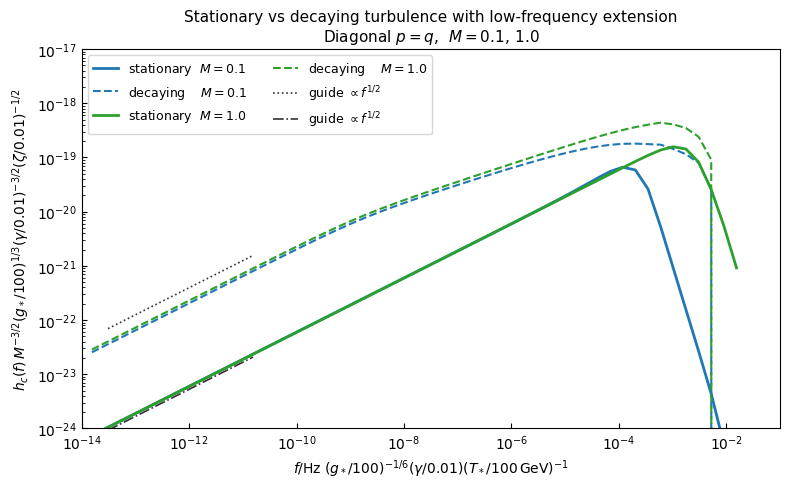

Saved: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/stationary_vs_decaying_low_frequency_full_band.pdf


In [6]:
colors = {0.1: 'C0', 1.0: 'C2'}

fig, ax = plt.subplots(figsize=(8, 5))
for m_idx, M in enumerate(M_compare):
    ax.loglog(scaled_freq_dec, sc_stat_all[m_idx], color=colors[M], lw=2.0, label=f'stationary  $M={M}$')
    ax.loglog(scaled_freq_dec, sc_dec_all[m_idx], color=colors[M], lw=1.5, ls='--', label=f'decaying    $M={M}$')

pow1 = 1.0 / 2.0
pow2 = 1.0 / 2.0
idx_anchor = min(4, len(scaled_freq_dec) - 1)
f_anchor = scaled_freq_dec[idx_anchor]
y_anchor = 1.15 * np.nanmax(np.hstack([sc_stat_all[:, idx_anchor], sc_dec_all[:, idx_anchor]]))
guide_stop_idx = min(10, len(scaled_freq_dec) - 1)
f_guide = np.array([scaled_freq_dec[1], scaled_freq_dec[guide_stop_idx]])
guide_k1 = 1.5 * y_anchor * (f_guide / f_anchor) ** pow1
guide_k2 = 0.02 * y_anchor * (f_guide / f_anchor) ** pow2

ax.loglog(f_guide, guide_k1, color='0.2', lw=1.2, ls=':', label=r'guide $\propto f^{1/2}$')
ax.loglog(f_guide, guide_k2, color='0.2', lw=1.2, ls='-.', label=r'guide $\propto f^{1/2}$')

ax.set_xlim(1e-14, 1e-1)
ax.set_ylim(1e-24, 1e-17)
ax.set_xlabel(r'$f/\mathrm{Hz}\;(g_*/100)^{-1/6}(\gamma/0.01)(T_*/100\,\mathrm{GeV})^{-1}$', fontsize=10)
ax.set_ylabel(r'$h_c(f)\,M^{-3/2}(g_*/100)^{1/3}(\gamma/0.01)^{-3/2}(\zeta/0.01)^{-1/2}$', fontsize=10)
ax.set_title('Stationary vs decaying turbulence with low-frequency extension\n' r'Diagonal $p = q$,  $M = 0.1,\,1.0$', fontsize=11)
ax.legend(fontsize=9, ncol=2)
ax.tick_params(which='both', direction='in')
fig.tight_layout()
plt.show()

full_band_pdf = os.path.join(out_dir, 'stationary_vs_decaying_low_frequency_full_band.pdf')
fig.savefig(full_band_pdf)
print(f'Saved: {full_band_pdf}')

## 5. Low-frequency zoom

This panel isolates the newly added low-frequency band so the infrared behavior of the decaying solution is easier to inspect.

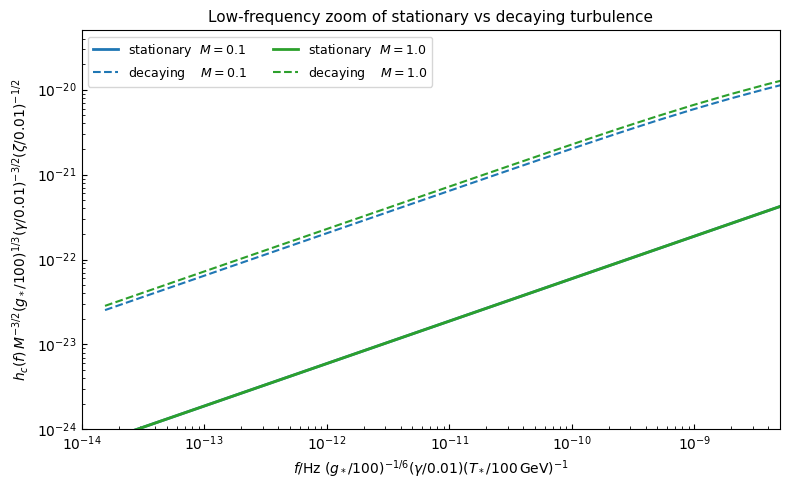

Saved: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/stationary_vs_decaying_low_frequency_zoom.pdf


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for m_idx, M in enumerate(M_compare):
    ax.loglog(scaled_freq_dec, sc_stat_all[m_idx], color=colors[M], lw=2.0, label=f'stationary  $M={M}$')
    ax.loglog(scaled_freq_dec, sc_dec_all[m_idx], color=colors[M], lw=1.5, ls='--', label=f'decaying    $M={M}$')

ax.set_xlim(1e-14, 5e-9)
ax.set_ylim(1e-24, 5e-20)
ax.set_xlabel(r'$f/\mathrm{Hz}\;(g_*/100)^{-1/6}(\gamma/0.01)(T_*/100\,\mathrm{GeV})^{-1}$', fontsize=10)
ax.set_ylabel(r'$h_c(f)\,M^{-3/2}(g_*/100)^{1/3}(\gamma/0.01)^{-3/2}(\zeta/0.01)^{-1/2}$', fontsize=10)
ax.set_title('Low-frequency zoom of stationary vs decaying turbulence', fontsize=11)
ax.legend(fontsize=9, ncol=2)
ax.tick_params(which='both', direction='in')
fig.tight_layout()
plt.show()

zoom_pdf = os.path.join(out_dir, 'stationary_vs_decaying_low_frequency_zoom.pdf')
fig.savefig(zoom_pdf)
print(f'Saved: {zoom_pdf}')